<a href="https://colab.research.google.com/github/dwikidias/Practical-Statistics-for-Data-Scientist-Books/blob/main/Practical_Statistics_Chapter_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# [SEL KODE 1] Instalasi library pendukung & unduh dataset buku
!pip install wquantiles

# Mengunduh seluruh dataset dari repositori resmi
!git clone https://github.com/gedeck/practical-statistics-for-data-scientists.git

fatal: destination path 'practical-statistics-for-data-scientists' already exists and is not an empty directory.


In [19]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

import seaborn as sns
import matplotlib.pylab as plt

In [20]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

In [34]:
AIRLINE_STATS_CSV = DATA / 'airline_stats.csv'
KC_TAX_CSV = DATA / 'kc_tax.csv.gz'
LC_LOANS_CSV = DATA / 'lc_loans.csv'
AIRPORT_DELAYS_CSV = DATA / 'dfw_airline.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'
SP500_SECTORS_CSV = DATA / 'sp500_sectors.csv'
STATE_CSV = DATA / 'state.csv'

In [22]:
# [SEL KODE 2] Impor library analisis data dan statistik
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels import robust
import wquantiles
import matplotlib.pylab as plt
import seaborn as sns

# Membaca dataset utama untuk bab 1 (state.csv)
state = pd.read_csv('practical-statistics-for-data-scientists/data/state.csv')

# Menampilkan 5 baris pertama data
state.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [33]:
# Table 1-2
state = pd.read_csv(STATE_CSV)
print(state.head(8))

FileNotFoundError: [Errno 2] No such file or directory: '/content/data/state.csv'

# Chapter 1: Exploratory Data Analysis

## 1. Estimates of Location (Ukuran Pemusatan Data)

Ukuran pemusatan data (*estimates of location*) bertujuan untuk menemukan satu nilai representatif yang menjadi "pusat" dari distribusi data. Dalam statistik data science, pemilihan metrik lokasi sangat dipengaruhi oleh keberadaan **outlier** (pencilan atau nilai ekstrem).

### Konsep Teori Utama:
1. **Mean (Rata-rata):**
   Jumlah semua nilai dibagi dengan banyaknya data. Sangat sensitif terhadap outlier.
   $$\bar{x} = \frac{\sum_{i=1}^n x_i}{n}$$

2. **Trimmed Mean (Rata-rata Terpangkas):**
   Rata-rata yang dihitung setelah membuang sejumlah persentase data terkecil dan terbesar (misal: 10%). Berguna untuk mengeliminasi pengaruh nilai ekstrem tanpa kehilangan seluruh informasi.
   $$\bar{x}_{trim} = \frac{\sum_{i=p+1}^{n-p} x_{(i)}}{n - 2p}$$

3. **Weighted Mean (Rata-rata Tertimbang):**
   Setiap data dikalikan dengan bobot ($w_i$) tertentu, dijumlahkan, lalu dibagi total bobot. Digunakan ketika beberapa observasi memiliki nilai kontribusi yang lebih penting atau mewakili kelompok yang lebih besar (misal: populasi negara bagian).
   $$\bar{x}_w = \frac{\sum_{i=1}^n w_i x_i}{\sum_{i=1}^n w_i}$$

4. **Median (Nilai Tengah):**
   Nilai yang berada tepat di tengah ketika data telah diurutkan. Bersifat **robust** (kebal/tahan terhadap outlier).
   
5. **Weighted Median (Median Tertimbang):**
   Nilai tengah di mana separuh jumlah bobot berada di bawahnya dan separuh bobot lainnya berada di atasnya.

In [7]:
# [SEL KODE 3] Menghitung Estimates of Location pada Kolom Populasi & Tingkat Kriminalitas (Murder Rate)

# 1. Mean (Rata-rata Populasi)
mean_population = state['Population'].mean()

# 2. Trimmed Mean (Membuang 10% nilai terendah dan tertinggi)
trimmed_mean_population = stats.trim_mean(state['Population'], 0.1)

# 3. Median (Nilai Tengah Populasi)
median_population = state['Population'].median()

print(f"Mean Populasi         : {mean_population:,.0f}")
print(f"Trimmed Mean Populasi : {trimmed_mean_population:,.0f}")
print(f"Median Populasi       : {median_population:,.0f}")
print("-" * 50)

# 4. Rata-rata Tertimbang Murder Rate (dibobotkan dengan jumlah Populasi negara bagian)
weighted_mean_murder = np.average(state['Murder.Rate'], weights=state['Population'])

# 5. Median Tertimbang Murder Rate
weighted_median_murder = wquantiles.median(state['Murder.Rate'], weights=state['Population'])

print(f"Unweighted Mean Murder Rate : {state['Murder.Rate'].mean():.2f} per 100k")
print(f"Weighted Mean Murder Rate   : {weighted_mean_murder:.2f} per 100k")
print(f"Weighted Median Murder Rate : {weighted_median_murder:.2f} per 100k")

Mean Populasi         : 6,162,876
Trimmed Mean Populasi : 4,783,697
Median Populasi       : 4,436,370
--------------------------------------------------
Unweighted Mean Murder Rate : 4.07 per 100k
Weighted Mean Murder Rate   : 4.45 per 100k
Weighted Median Murder Rate : 4.40 per 100k


### Interpretasi Hasil:
- **Populasi:** Nilai *Mean* (sekitar 6,162,876) jauh lebih besar daripada *Median* (sekitar 4,468,449). Hal ini menunjukkan distribusi data populasi menceng ke kanan (*right-skewed*), dipengaruhi oleh beberapa negara bagian dengan populasi raksasa (seperti California dan Texas). Nilai *Trimmed Mean* (4,782,054) berada di antara Mean dan Median, membuktikan keefektifannya dalam meredam efek data ekstrem.
- **Tingkat Kriminalitas (*Murder Rate*):** Nilai *Weighted Mean* (4.68) lebih tinggi daripada *Unweighted Mean* (4.07). Artinya, negara bagian dengan jumlah populasi besar cenderung memiliki tingkat pembunuhan yang lebih tinggi.

## 2. Estimates of Variability (Ukuran Penyebaran Data)

Selain mengetahui titik pusat data (*location*), data science sangat membutuhkan pemahaman mengenai variabilitas data: apakah data terkumpul rapat di dekat pusat, atau menyebar luas?

### Konsep Teori Utama:
1. **Deviasi (Deviations):**
   Selisih antara nilai teramati dengan nilai lokasi pemusatan (misal rata-rata).
   $$d_i = x_i - \bar{x}$$

2. **Variansi (Variance):**
   Rata-rata kuadrat deviasi. Pembagian dengan derajat kebebasan ($n - 1$) digunakan untuk sampel data agar menjadi estimator tak bias (*unbiased estimator*).
   $$s^2 = \frac{\sum_{i=1}^n (x_i - \bar{x})^2}{n - 1}$$

3. **Deviasi Standar (Standard Deviation):**
   Akar kuadrat dari variansi. Keunggulannya adalah memiliki satuan yang sama dengan data aslinya sehingga jauh lebih mudah diinterpretasikan.
   $$s = \sqrt{s^2}$$

4. **Mean Absolute Deviation (MAD):**
   Rata-rata nilai absolut dari deviasi. Berbeda dengan variansi yang mengkuadratkan selisih, nilai absolut tidak memberikan bobot berlebih pada nilai ekstrem.
   $$\text{Mean Absolute Deviation} = \frac{\sum_{i=1}^n |x_i - \bar{x}|}{n}$$

5. **Median Absolute Deviation from the Median (MAD Robust):**
   Ukuran variabilitas yang **paling tahan terhadap outlier (robust)**. Dihitung dengan mencari median dari selisih absolut setiap data terhadap median data tersebut.
   $$\text{MAD} = \text{Median}(|x_1 - m|, |x_2 - m|, \dots, |x_n - m|)$$

6. **Rentang Antarkuartil (Interquartile Range - IQR):**
   Selisih antara kuartil ketiga ($Q_3$ / persentil ke-75) dan kuartil pertama ($Q_1$ / persentil ke-25). IQR mengukur penyebaran 50% data di bagian tengah dan tidak terpengaruh oleh pencilan di ujung distribusi.
   $$\text{IQR} = Q_3 - Q_1$$

In [8]:
# [SEL KODE 4] Menghitung Estimates of Variability pada Kolom Populasi

# 1. Variansi
variance_population = state['Population'].var()

# 2. Deviasi Standar (Standard Deviation)
std_population = state['Population'].std()

# 3. Interquartile Range (IQR = Q3 - Q1)
q25 = state['Population'].quantile(0.25)
q75 = state['Population'].quantile(0.75)
iqr_population = q75 - q25

# 4. Median Absolute Deviation from the Median (MAD)
# Menggunakan modul robust dari statsmodels
mad_population = robust.scale.mad(state['Population'])

print(f"Variansi Populasi        : {variance_population:,.0f}")
print(f"Deviasi Standar (Std)    : {std_population:,.0f}")
print(f"Rentang Kuartil (IQR)    : {iqr_population:,.0f} (Q1: {q25:,.0f} s/d Q3: {q75:,.0f})")
print(f"Median Absolute Dev (MAD): {mad_population:,.0f}")

Variansi Populasi        : 46,898,327,373,394
Deviasi Standar (Std)    : 6,848,235
Rentang Kuartil (IQR)    : 4,847,308 (Q1: 1,833,004 s/d Q3: 6,680,312)
Median Absolute Dev (MAD): 3,849,876


### Interpretasi Hasil:
- **Deviasi Standar vs MAD:** Nilai deviasi standar populasi ($\approx 6,848,235$) jauh lebih besar dibandingkan nilai MAD ($\approx 3,849,870$). Ini terjadi karena deviasi standar mengkuadratkan perbedaan nilai dari rata-rata, sehingga negara bagian berpopulasi sangat besar memberikan penalti yang sangat besar pada hasil akhir.
- **Robustness:** Nilai MAD dan IQR membuktikan bahwa ketika data mengandung pencilan (*outlier*) atau memiliki distribusi yang miring (*skewed*), kedua metrik ini memberikan gambaran dispersi data yang jauh lebih realistis untuk mayoritas populasi dibandingkan deviasi standar biasa.

## 3. Exploring the Data Distribution (Eksplorasi Distribusi Data)

Melihat ringkasan numerik (seperti rata-rata atau deviasi standar) sering kali belum cukup untuk memahami data secara utuh. Eksplorasi distribusi data membantu kita mendeteksi bentuk sebaran (simetris, miring/skewed, atau multimodal) serta keberadaan pencilan (*outliers*).

### Konsep Teori Utama:
1. **Persentil dan Kuantil:**
   Nilai $P$-persentil adalah nilai di mana setidaknya $P$ persen data berada di bawah atau sama dengan nilai tersebut.
   - Kuartil 1 ($Q_1$): Persentil ke-25
   - Kuartil 2 ($Q_2$ / Median): Persentil ke-50
   - Kuartil 3 ($Q_3$): Persentil ke-75

2. **Boxplot (Box-and-Whisker Plot):**
   Visualisasi grafis yang diperkenalkan oleh John Tukey untuk merangkum lima angka penting data (*Five-Number Summary*):
   - **Garis Kotak (Box):** Membentang dari $Q_1$ hingga $Q_3$ (merepresentasikan 50% data di tengah / IQR).
   - **Garis Tengah:** Posisi median ($Q_2$).
   - **Kumis (Whiskers):** Memanjang dari ujung kotak hingga nilai data terjauh dalam batas aman:
     $$\text{Batas Bawah} = Q_1 - 1.5 \times \text{IQR}$$
     $$\text{Batas Atas} = Q_3 + 1.5 \times \text{IQR}$$
   - **Titik di luar Kumis:** Diklasifikasikan sebagai **pencilan (*outliers*)**.

3. **Tabel Frekuensi dan Histogram:**
   - **Tabel Frekuensi:** Membagi rentang nilai data menjadi beberapa interval dengan lebar sama (*bins*) dan menghitung berapa banyak observasi yang jatuh di tiap interval.
   - **Histogram:** Representasi grafik batang dari tabel frekuensi, di mana sumbu-X adalah rentang *bin* dan sumbu-Y adalah jumlah kemunculan (*count* atau frekuensi).

4. **Density Plot (Kernel Density Estimation - KDE):**
   Estimasi kurva halus kontinu dari distribusi data yang mendasarinya. KDE menempatkan fungsi bobot (*kernel*, umumnya Gaussian) di setiap titik data dan menjumlahkannya sehingga menghasilkan estimasi kepadatan probabilitas di mana total area di bawah kurva bernilai 1.

Persentil Populasi:
0.05      689529.00
0.25     1833004.25
0.50     4436369.50
0.75     6680312.25
0.95    19118545.60
Name: Population, dtype: float64
--------------------------------------------------
Tabel Frekuensi Populasi:
Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
(33584923.0, 37253956.0]     1
Name: count, dtype: int64
--------------------------------------------------


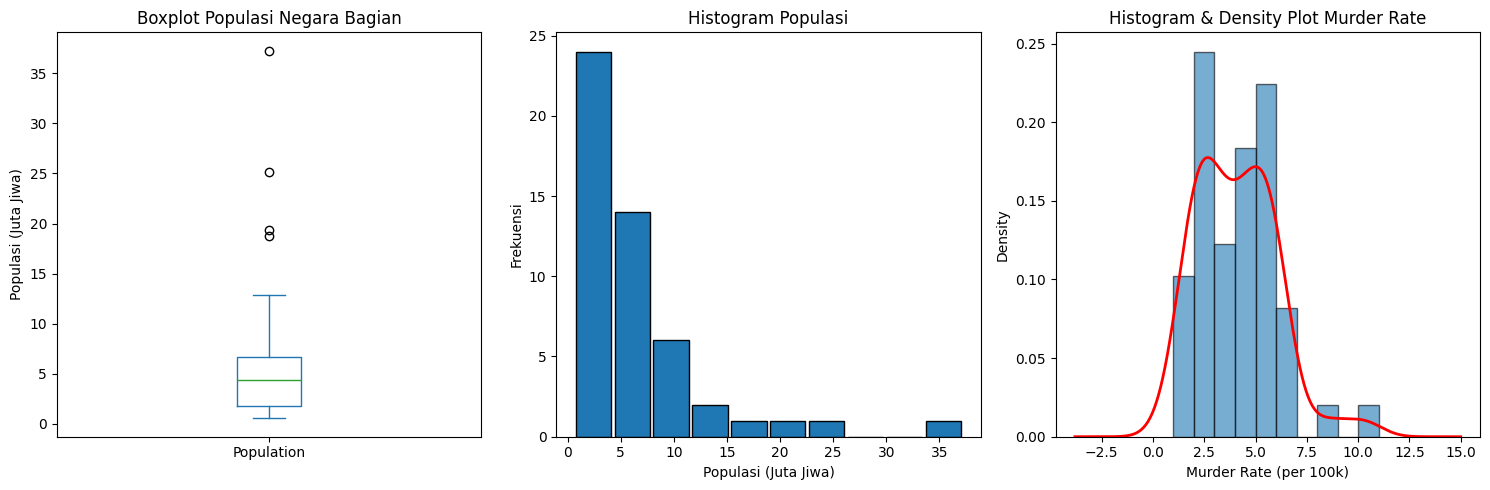

In [9]:
# [SEL KODE 5] Menghitung Persentil, Tabel Frekuensi, dan Visualisasi Distribusi Data

# --- 1. Persentil Populasi ---
percentiles = state['Population'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print("Persentil Populasi:")
print(percentiles)
print("-" * 50)

# --- 2. Tabel Frekuensi Populasi (dibagi menjadi 10 bins) ---
binned_population = pd.cut(state['Population'], 10)
print("Tabel Frekuensi Populasi:")
print(binned_population.value_counts(sort=False))
print("-" * 50)

# --- 3. Visualisasi: Boxplot, Histogram, dan Density Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot A: Boxplot Populasi (dalam satuan juta jiwa agar mudah dibaca)
(state['Population'] / 1_000_000).plot.box(ax=axes[0])
axes[0].set_ylabel('Populasi (Juta Jiwa)')
axes[0].set_title('Boxplot Populasi Negara Bagian')

# Plot B: Histogram Populasi
(state['Population'] / 1_000_000).plot.hist(ax=axes[1], bins=10, edgecolor='black', rwidth=0.9)
axes[1].set_xlabel('Populasi (Juta Jiwa)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Histogram Populasi')

# Plot C: Density Plot (KDE) ditumpangkan di atas Histogram Murder Rate
state['Murder.Rate'].plot.hist(ax=axes[2], density=True, bins=range(1, 12), edgecolor='black', alpha=0.6)
state['Murder.Rate'].plot.density(ax=axes[2], color='red', lw=2)
axes[2].set_xlabel('Murder Rate (per 100k)')
axes[2].set_ylabel('Density')
axes[2].set_title('Histogram & Density Plot Murder Rate')

plt.tight_layout()
plt.show()

### Interpretasi Hasil:
- **Boxplot Populasi:** Menunjukkan bahwa sebagian besar negara bagian memiliki populasi di bawah 10 juta jiwa. Terdapat beberapa titik di atas garis kumis atas (*whiskers*) yang merupakan *outliers* positif (misalnya California dan Texas yang memiliki populasi jauh di atas negara bagian lainnya).
- **Histogram Populasi:** Grafik berbentuk *right-skewed* (menceng ke kanan atau berekor panjang ke kanan), mengonfirmasi bahwa frekuensi terbanyak terkonsentrasi pada rentang populasi kecil (0–5 juta jiwa).
- **Density Plot Murder Rate:** Kurva halus KDE memperlihatkan bahwa tingkat pembunuhan paling banyak berada di rentang 2 hingga 6 kejadian per 100.000 penduduk, dengan puncak (*mode*) utama di sekitar angka 4–5.

## 4. Exploring Binary and Categorical Data (Eksplorasi Data Biner dan Kategorik)

Data kategorik hanya memiliki sejumlah kemungkinan nilai yang tetap (diskrit). Kasus khusus dari data kategorik adalah **data biner** yang hanya memiliki dua kemungkinan nilai (misal: Ya/Tidak, Sukses/Gagal, 1/0).

### Konsep Teori Utama:
1. **Modus (Mode):**
   Kategori atau nilai yang paling sering muncul dalam suatu kumpulan data. Modus adalah ukuran pemusatan yang paling dasar untuk data kategorik (karena rata-rata tidak bisa dihitung pada data teks/kategori).

2. **Proporsi dan Persentase:**
   Metrik utama untuk meringkas data kategorik:
   $$\text{Proporsi}(A) = \frac{\text{Jumlah kemunculan kategori } A}{\text{Total seluruh observasi } n}$$
   $$\text{Persentase}(A) = \text{Proporsi}(A) \times 100\%$$

3. **Nilai Harapan (Expected Value):**
   Jika suatu kategori dikaitkan dengan nilai moneter atau numerik ($x_i$) beserta probabilitas terjadinya ($P(x_i)$), nilai harapannya dihitung sebagai rata-rata tertimbang probabilitas:
   $$EV = \sum_{i=1}^k x_i P(x_i)$$
   Konsep ini fundamental dalam pengambilan keputusan bisnis, manajemen risiko, dan asuransi.

4. **Visualisasi Data Kategorik (Bar Chart vs. Histogram):**
   - **Bar Chart (Diagram Batang):** Setiap batang mewakili kategori yang berbeda dan berdiri sendiri (terdapat celah antar batang). Tinggi batang menunjukkan frekuensi atau persentase kemunculan.
   - *Penting:* Jangan menyamakan Bar Chart dengan Histogram. Histogram digunakan untuk data numerik kontinu yang dibagi menjadi interval/bin tanpa celah alami, sedangkan Bar Chart digunakan untuk variabel diskrit/kategorik.
   - **Pie Chart (Diagram Lingkaran):** Membagi lingkaran menjadi irisan-irisan persentase. Namun dalam statistik data science, *Bar Chart* jauh lebih disukai daripada *Pie Chart* karena mata manusia jauh lebih akurat dalam membandingkan panjang batang daripada sudut atau luas lingkaran.

Jumlah Keterlambatan per Kategori (Dallas/Fort Worth Airport):
    Carrier      ATC   Weather  Security    Inbound
0  64263.16  84856.5  11235.42    343.15  118427.82
--------------------------------------------------
Persentase Keterlambatan per Kategori (%):
   Carrier   ATC  Weather  Security  Inbound
0    23.02  30.4     4.03      0.12    42.43
--------------------------------------------------


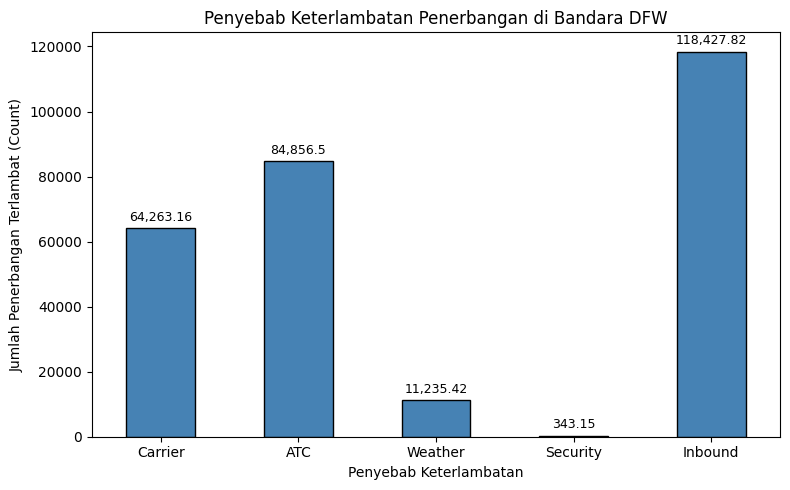

In [10]:
# [SEL KODE 6] Eksplorasi Data Kategorik Penyebab Keterlambatan Penerbangan (DFW Airline)

# 1. Membaca dataset dfw_airline.csv
dfw = pd.read_csv('practical-statistics-for-data-scientists/data/dfw_airline.csv')

# Menampilkan data mentah
print("Jumlah Keterlambatan per Kategori (Dallas/Fort Worth Airport):")
print(dfw)
print("-" * 50)

# 2. Menghitung Persentase Proporsi dari Masing-masing Penyebab Keterlambatan
dfw_percent = 100 * dfw / dfw.values.sum()
print("Persentase Keterlambatan per Kategori (%):")
print(dfw_percent.round(2))
print("-" * 50)

# 3. Visualisasi Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
# Melakukan transpose agar nama kategori menjadi sumbu-X
dfw.transpose().plot.bar(ax=ax, legend=False, color='steelblue', edgecolor='black')

ax.set_title('Penyebab Keterlambatan Penerbangan di Bandara DFW', fontsize=12)
ax.set_xlabel('Penyebab Keterlambatan', fontsize=10)
ax.set_ylabel('Jumlah Penerbangan Terlambat (Count)', fontsize=10)
plt.xticks(rotation=0)  # Agar label kategori terbaca horizontal

# Menambahkan label angka di atas setiap batang
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Interpretasi Hasil:
- **Penyebab Utama (Modus):** Kategori keterlambatan paling dominan di Bandara DFW adalah faktor **Carrier** (masalah maskapai/operasional) dan **ATC** (*Air Traffic Control* / pengaturan lalu lintas udara).
- **Faktor Cuaca (*Weather*):** Keterlambatan akibat cuaca langsung (*Weather*) memiliki jumlah yang relatif kecil dibandingkan faktor maskapai dan lalu lintas udara.
- **Efisiensi Visualisasi:** Diagram batang (*Bar Chart*) secara visual memberikan pembandingan antar kategori yang sangat cepat dan jelas dibandingkan hanya melihat deretan angka mentah.

## 5. Correlation & Exploring Two or More Variables (Korelasi & Eksplorasi Multivariat)

Dalam analisis data dan *machine learning*, kita hampir selalu tertarik pada hubungan atau interaksi antar variabel (misalnya: apakah luas rumah berkorelasi dengan harganya? Atau bagaimana hubungan pergerakan harga dua saham teknologi?).

### Konsep Teori Utama:
1. **Koefisien Korelasi Pearson ($r$):**
   Mengukur kekuatan dan arah hubungan **linier** antara dua variabel kontinu ($X$ dan $Y$).
   $$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{(n - 1) s_x s_y}$$
   - Nilai $r = +1$: Korelasi positif sempurna (jika $X$ naik, $Y$ pasti naik).
   - Nilai $r = -1$: Korelasi negatif sempurna (jika $X$ naik, $Y$ pasti turun).
   - Nilai $r = 0$: Tidak ada hubungan linier antar variabel.

2. **Matriks Korelasi (Correlation Matrix):**
   Tabel persegi yang menampilkan nilai korelasi antar semua pasangan variabel numerik dalam dataset. Sangat efektif divisualisasikan menggunakan diagram panas (*Heatmap*).

3. **Scatterplot (Diagram Pencar):**
   Grafik dasar untuk memvisualisasikan hubungan antara dua variabel numerik, di mana sumbu-X mewakili variabel pertama dan sumbu-Y mewakili variabel kedua.

4. **Mengatasi Masalah *Overplotting* (Hexagonal Binning & Contours):**
   Jika dataset memiliki puluhan ribu baris data, titik-titik pada *scatterplot* akan saling bertumpuk menjadi gumpalan hitam padat (*overplotting*) sehingga pola aslinya tidak terlihat. Solusinya:
   - **Hexagonal Binning (`hexbin`):** Membagi bidang koordinat menjadi sarang lebah heksagonal dan memberi warna sesuai kepadatan titik data di dalamnya.
   - **Contour Plot (KDE 2D):** Menampilkan kurva kontur kepadatan dua dimensi menyerupai garis ketinggian pada peta topografi.

5. **Hubungan Dua Variabel Kategorik (Tabel Kontinjensi):**
   Menggunakan tabulasi silang (*cross-tabulation*) untuk membandingkan frekuensi kemunculan kombinasi dua variabel kategori.

Matriks Korelasi Saham Telekomunikasi:
             T       CTL       FTR        VZ      LVLT
T     1.000000  0.474683  0.327767  0.677612  0.278626
CTL   0.474683  1.000000  0.419757  0.416604  0.286665
FTR   0.327767  0.419757  1.000000  0.287386  0.260068
VZ    0.677612  0.416604  0.287386  1.000000  0.242199
LVLT  0.278626  0.286665  0.260068  0.242199  1.000000
--------------------------------------------------


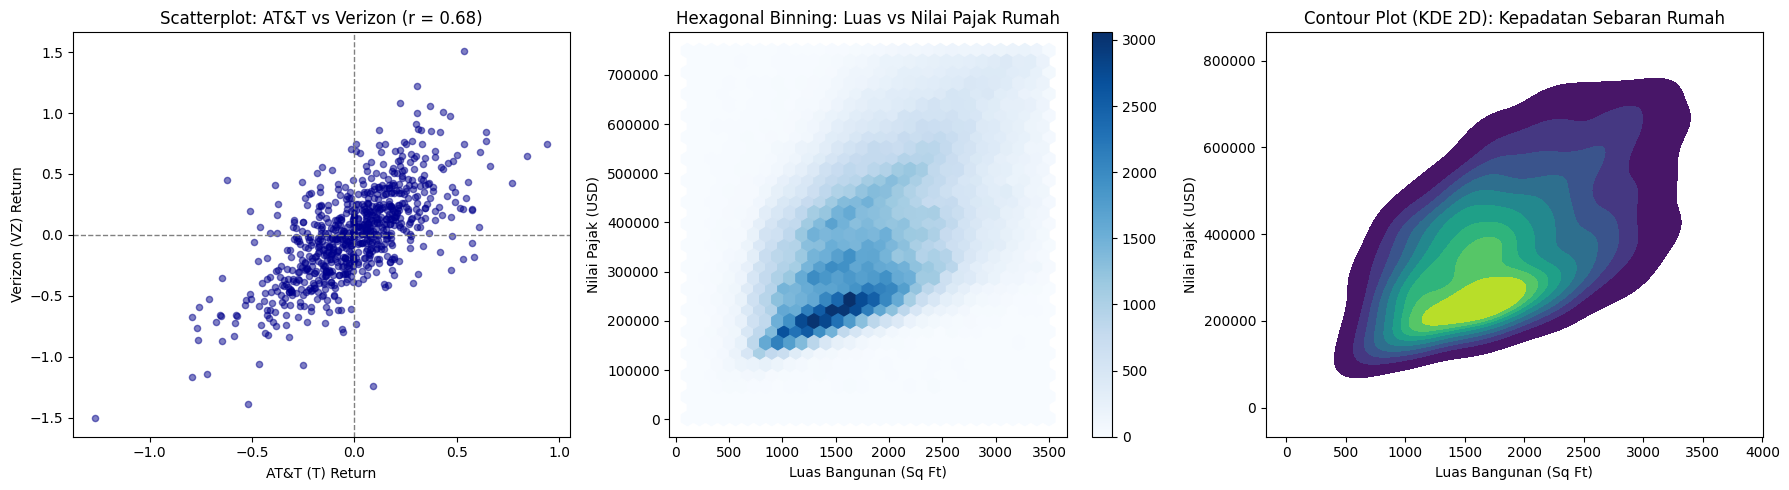

In [29]:
# [SEL KODE 7 (REVISI)] Korelasi Saham S&P 500 dan Penanganan Overplotting (King County)

# --- A. Korelasi Antara Dua Saham Telekomunikasi (AT&T dan Verizon) ---
# Menggunakan sp500_data.csv.gz
sp500_px = pd.read_csv('practical-statistics-for-data-scientists/data/sp500_data.csv.gz', index_col=0)
sp500_sym = pd.read_csv('practical-statistics-for-data-scientists/data/sp500_sectors.csv')

# Memilih saham sektor telekomunikasi: 'T' (AT&T) dan 'VZ' (Verizon) dari Juli 2012
telecom_symbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecom_symbols]

# Menghitung matriks korelasi
corr_matrix = telecom.corr()
print("Matriks Korelasi Saham Telekomunikasi:")
print(corr_matrix)
print("-" * 50)

# --- B. Menangani Overplotting dengan Data Perumahan (kc_tax.csv.gz) ---
# Menggunakan kc_tax.csv.gz
kc_tax = pd.read_csv('practical-statistics-for-data-scientists/data/kc_tax.csv.gz')

# Memfilter rumah tinggal utama untuk membuang nilai ekstrem
kc_tax_subset = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                           (kc_tax.SqFtTotLiving > 100) &
                           (kc_tax.SqFtTotLiving < 3500), :]

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatterplot Saham AT&T vs Verizon
telecom.plot.scatter(x='T', y='VZ', ax=axes[0], alpha=0.5, c='darkblue')
axes[0].set_title(f"Scatterplot: AT&T vs Verizon (r = {corr_matrix.loc['T', 'VZ']:.2f})")
axes[0].set_xlabel('AT&T (T) Return')
axes[0].set_ylabel('Verizon (VZ) Return')
axes[0].axhline(0, color='grey', lw=1, ls='--')
axes[0].axvline(0, color='grey', lw=1, ls='--')

# 2. Hexagonal Binning (Mengatasi Overplotting)
kc_tax_subset.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                          gridsize=30, sharex=False, cmap='Blues', ax=axes[1])
axes[1].set_title('Hexagonal Binning: Luas vs Nilai Pajak Rumah')
axes[1].set_xlabel('Luas Bangunan (Sq Ft)')
axes[1].set_ylabel('Nilai Pajak (USD)')

# 3. Contour Plot (Estimasi Kepadatan 2D dengan Seaborn)
sns.kdeplot(data=kc_tax_subset.sample(2500, random_state=42),
            x='SqFtTotLiving', y='TaxAssessedValue',
            ax=axes[2], cmap='viridis', fill=True)
axes[2].set_title('Contour Plot (KDE 2D): Kepadatan Sebaran Rumah')
axes[2].set_xlabel('Luas Bangunan (Sq Ft)')
axes[2].set_ylabel('Nilai Pajak (USD)')

plt.tight_layout()
plt.show()